# Calcium Imaging → Spike Inference Pipeline (`main.ipynb`)

An end-to-end, **reusable** pipeline for one-photon calcium-imaging recordings stored as
one `.npy` frame per timepoint (`ImageData_Ch<CHANNEL>_TP*.npy`). Point the **Config**
cell at your data, then run top-to-bottom. Frames are streamed one at a time (the full
stack is many GB) and every expensive step is cached under `analysis_cache/`, so re-runs
are fast.

## What this notebook does

| Step | Section | What happens |
|---|---|---|
| **Input** | 1 | Index the `.npy` frames and read the real per-frame acquisition times. |
| **Preprocess** | 2 | **2a** compares raw vs **NLM** vs **Gaussian**; **2b** you pick the method + params, then it denoises and background-subtracts every frame (cached). |
| **Visualize** | 3 | (a) **ROIs (from your label TIFF) marked** on the max-projection map; (b) **MP4** of the whole field with the **ROI mask overlaid**; (c) **dF/F trace of every ROI**. An optional **napari** cell (off by default) opens the interactive viewer. |
| **Spike inference** | 4 | Feed each ROI's dF/F to the **DS40-pretrained CASCADE** model (runs in the dedicated `CASCADE` env via `run_cascade_ds40.py`). |
| **Correlation** | 5 | Two ROI × ROI correlation heatmaps: **5a** dF/F, **5b** inferred spike rate. |

## How to run (short version)

1. Edit only the **Config** cell — set `DATA_DIR`, `CHANNEL`, and `ROI_LABEL_PATH`.
2. Run every cell top-to-bottom. In **§2b** choose the denoise method (`"nlm"` or `"gaussian"`).
   The napari cell stays skipped unless you set `USE_NAPARI = True`.
3. For §4 (CASCADE), point `CASCADE_ENV_PYTHON` at the Python of a conda env that has
   TensorFlow/Keras + the CASCADE source under `CASCADE_ROOT`.

**Saving outputs:** by default figures and the movie are shown **inline only** (stored in the
notebook) — nothing extra is written to the project. Set `SAVE_OUTPUTS = True` in the cell
right after §1 to also export PNGs/MP4 to `main_output/` (`/main/main_output` in a clone).

## Requirements

`numpy`, `matplotlib`, `scikit-image`, `scipy`, `tifffile`, `pyyaml`, `tqdm`
(+ `ffmpeg` on PATH for the MP4, and optionally `napari`/`dask` for the interactive cell).
ROIs are supplied as an integer **label TIFF** (`0` = background, `1..N` = ROIs); paint your
own in the napari cell if you don't have one yet.

## Imports

In [25]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile
import yaml

try:
    from tqdm.auto import tqdm
except ImportError:                       # tqdm is optional -- degrade to a no-op
    def tqdm(iterable=None, **kwargs):
        return iterable

%matplotlib inline

## Config

**The only cell you normally edit.** Everything downstream reads from here.

In [26]:
# --- Data location -------------------------------------------------------------
# Frames are one .npy per timepoint, named ImageData_Ch<CHANNEL>_TP<#######>.npy
DATA_DIR = Path("raw")            # local SlideBook-style export used here
# If you CLONED this repo, use the bundled sample data instead:
#   DATA_DIR = Path("KSLSpikeInference/input_data")
# Data format is always .npy (one frame per file).
CHANNEL = 0                       # which Ch<N> to analyze

CACHE_DIR = Path("analysis_cache")
CACHE_DIR.mkdir(exist_ok=True)    # working/cached files (safe to delete)

# --- ROIs: integer label TIFF (0 = background, 1..N = one ROI each) -------------
ROI_LABEL_PATH = Path("/Users/samsonho/KSL/leftDRGcut/_labels/Debi_DRG_ROI.tiff")
# If you CLONED this repo, store your ROI '.tiff' mask files under /main/labels/
# (i.e. /main/labels/{your ROI '.tiff' mask files here}) and point this there:
#   ROI_LABEL_PATH = Path("/main/labels/<your_ROI_mask>.tiff")

# --- dF/F: rolling low-percentile baseline --------------------------------------
BASELINE_PERCENTILE = 10  # ~inactive baseline level
BASELINE_WINDOW_S = 15    # rolling window length (s)

# --- CASCADE DS40 spike inference (section 4) -----------------------------------
CASCADE_ENV_PYTHON = Path("/Users/samsonho/exit()/envs/CASCADE/bin/python")  # env WITH TensorFlow
CASCADE_ROOT = Path("cascade_runtime")          # holds cascade2p/ + Pretrained_models/
CASCADE_BRIDGE = Path("run_cascade_ds40.py")    # subprocess bridge shipped with this repo
CASCADE_MODEL_NAME = "Spinal_cord_excitatory_30Hz_smoothing50ms"

# --- Interactive napari viewer: OFF by default (see the napari cell in section 3) --
USE_NAPARI = False

# NOTE: the denoise method + its parameters live in section 2 (cell 2b) so you can
# compare NLM vs Gaussian in 2a before committing to one.

## 1. Input — index the `.npy` frames and the time axis

Builds a timepoint-ordered list of frame paths and reads the real acquisition times from
`ElapsedTimes.yaml` (falling back to a nominal 10 Hz axis if it is missing or mismatched).
Nothing is loaded into RAM yet — `load_frame(i)` reads a single frame on demand.

In [27]:
_TP_RE = re.compile(r"_TP(\d+)\.npy$")


def build_index(data_dir: Path = DATA_DIR, channel: int = CHANNEL) -> list[Path]:
    files = [p for p in data_dir.glob(f"ImageData_Ch{channel}_TP*.npy") if _TP_RE.search(p.name)]
    if not files:
        raise FileNotFoundError(
            f"No frames matched {data_dir}/ImageData_Ch{channel}_TP*.npy -- "
            "check DATA_DIR and CHANNEL in the Config cell."
        )
    return sorted(files, key=lambda p: int(_TP_RE.search(p.name).group(1)))


def load_time_axis(n_frames: int, data_dir: Path = DATA_DIR) -> np.ndarray:
    """Per-frame acquisition time in seconds (starts at 0)."""
    yaml_path = data_dir / "ElapsedTimes.yaml"
    if yaml_path.is_file():
        raw = yaml.safe_load(open(yaml_path))["theElapsedTimes"][1:]  # [0] is a count, not a time
        t = np.asarray(raw, dtype=float)[:n_frames] / 1000.0
        if len(t) == n_frames:
            return t - t[0]
        print(f"! ElapsedTimes has {len(raw)} entries but {n_frames} frames; using nominal 10 Hz.")
    return np.arange(n_frames, dtype=float) / 10.0


def load_frame(i: int) -> np.ndarray:
    """One raw (H, W) frame, untouched."""
    return np.load(image_files[i]).squeeze(axis=0)


image_files = build_index()
n_frames = len(image_files)
times_s = load_time_axis(n_frames)
frame_shape = load_frame(0).shape
fps_native = 1.0 / np.median(np.diff(times_s))
print(f"{n_frames} frames of {frame_shape} over {times_s[-1]:.1f} s (~{fps_native:.1f} Hz)")

3220 frames of (1024, 1376) over 322.2 s (~10.0 Hz)


## Output saving (optional)

Choose whether to **also** write figures (PNG) and the movie (MP4) to disk. By default
`SAVE_OUTPUTS = False`, so everything is only shown inline and lives inside the notebook —
nothing is written to `main_output/`. Flip it to `True` to additionally export to
`OUTPUT_DIR` (`main_output/`, which will be `/main/main_output` in a cloned repo).

In [28]:
# By default, figures and the movie are only shown inline (and stored in this
# notebook) -- nothing extra is written to the project. Set SAVE_OUTPUTS = True to
# ALSO save every figure (PNG) and the movie (MP4) into OUTPUT_DIR.
SAVE_OUTPUTS = False
OUTPUT_DIR = Path("main_output")   # in a cloned repo this path will be /main/main_output

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Write fig to OUTPUT_DIR/<name>.png -- but only when SAVE_OUTPUTS is True."""
    if SAVE_OUTPUTS:
        fig.savefig(OUTPUT_DIR / f"{name}.png", dpi=200, bbox_inches="tight")


print(
    f"SAVE_OUTPUTS = {SAVE_OUTPUTS} -> "
    + (f"also writing PNG/MP4 to {OUTPUT_DIR}/" if SAVE_OUTPUTS
       else "figures/movie shown inline only (nothing written to main_output)")
)

SAVE_OUTPUTS = False -> figures/movie shown inline only (nothing written to main_output)


## 2. Preprocess — denoise + background subtraction

Every frame gets two steps before analysis: **denoise** then subtract a per-frame
background percentile (a flat offset that pins the noise floor near zero).

- **2a** previews `raw` vs **NLM** vs **Gaussian** on the first frame, using the suggested
  default parameters, so you can eyeball which denoiser to use.
- **2b** lets you pick the method (`"nlm"` or `"gaussian"`) and tune its parameters (defaults
  provided), then builds the cached `load_preprocessed(i)` that every downstream section uses.

### 2a. Compare denoisers (raw vs NLM vs Gaussian, default params)

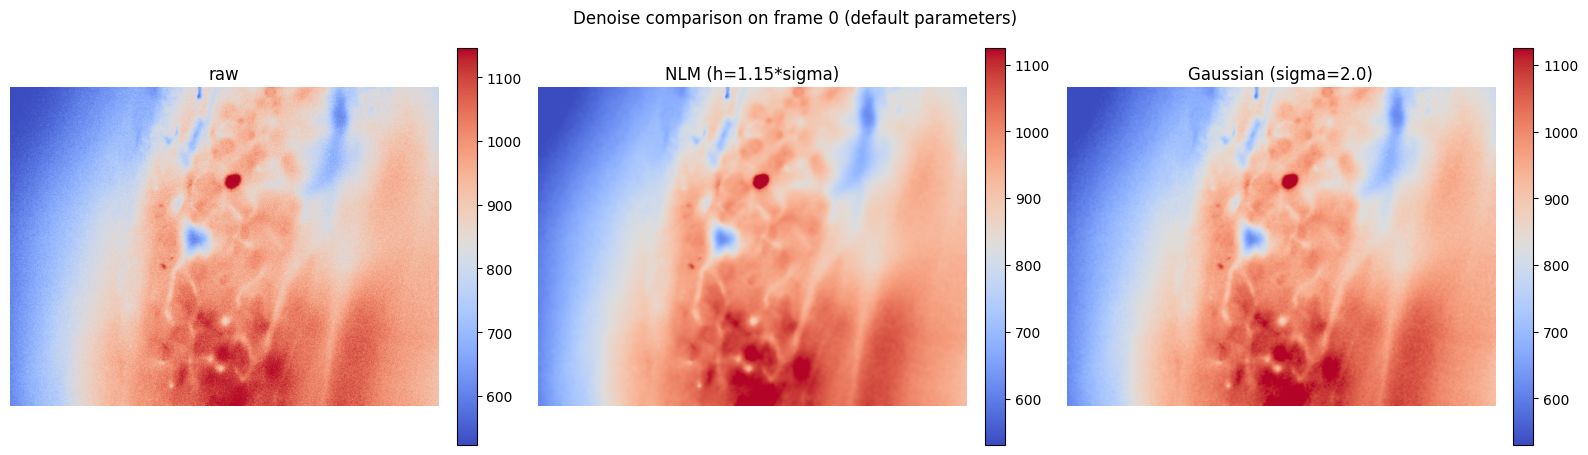

In [29]:
from scipy.ndimage import convolve as _ndconvolve, gaussian_filter
from skimage.restoration import denoise_nl_means

# --- Suggested default denoise parameters (override them in 2b if you like) -----
NLM_PATCH_SIZE = 5        # px, patch size for patch-distance comparison
NLM_PATCH_DISTANCE = 6    # px, max search radius for similar patches
NLM_H_FACTOR = 1.15       # NLM cut-off distance, scaled by the estimated noise sigma
GAUSSIAN_SIGMA = 2.0      # px, Gaussian blur width

# Robust per-frame noise sigma via Immerkaer's Laplacian method (numpy/scipy only, so we
# avoid skimage.estimate_sigma, which needs PyWavelets). NLM scales its `h` by this.
_LAPLACIAN = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], dtype=np.float32)


def estimate_noise_sigma(frame: np.ndarray) -> float:
    h, w = frame.shape
    response = np.abs(_ndconvolve(frame, _LAPLACIAN, mode="nearest"))
    return float(response.sum() * np.sqrt(0.5 * np.pi) / (6.0 * (w - 2) * (h - 2)))


def denoise_nlm(frame, patch_size=None, patch_distance=None, h_factor=None):
    """Non-local-means denoise; params default to the suggestions above."""
    patch_size = NLM_PATCH_SIZE if patch_size is None else patch_size
    patch_distance = NLM_PATCH_DISTANCE if patch_distance is None else patch_distance
    h_factor = NLM_H_FACTOR if h_factor is None else h_factor
    sigma = estimate_noise_sigma(frame)
    return denoise_nl_means(frame, h=h_factor * sigma, sigma=sigma, fast_mode=True,
                            patch_size=patch_size, patch_distance=patch_distance, channel_axis=None)


def denoise_gaussian(frame, sigma=None):
    """Gaussian-blur denoise; sigma defaults to GAUSSIAN_SIGMA."""
    return gaussian_filter(frame, sigma=GAUSSIAN_SIGMA if sigma is None else sigma)


# Compare raw vs NLM vs Gaussian on the first frame, using the defaults above.
raw0 = load_frame(0).astype(np.float32)
panels = [
    ("raw", raw0),
    (f"NLM (h={NLM_H_FACTOR}*sigma)", denoise_nlm(raw0)),
    (f"Gaussian (sigma={GAUSSIAN_SIGMA})", denoise_gaussian(raw0)),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (title, img) in zip(axes, panels):
    vmin, vmax = np.percentile(img, [1, 99])
    im = ax.imshow(img, cmap="coolwarm", vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title); ax.axis("off")
fig.suptitle("Denoise comparison on frame 0 (default parameters)")
fig.tight_layout(); save_fig(fig, "2a_denoise_comparison"); plt.show()

### 2b. Choose the denoise method and parameters

Set `DENOISE_METHOD` to `"nlm"` or `"gaussian"` and adjust the parameters below (the values
shown are the suggested defaults). This cell defines `preprocess_frame` / `load_preprocessed`,
which cache one `.npy` per frame under `analysis_cache/` — keyed by method, so switching
method or params doesn't clash with a previous cache. NLM is ~0.5 s/frame, so the first full
pass is slow; later sections reuse the cache.

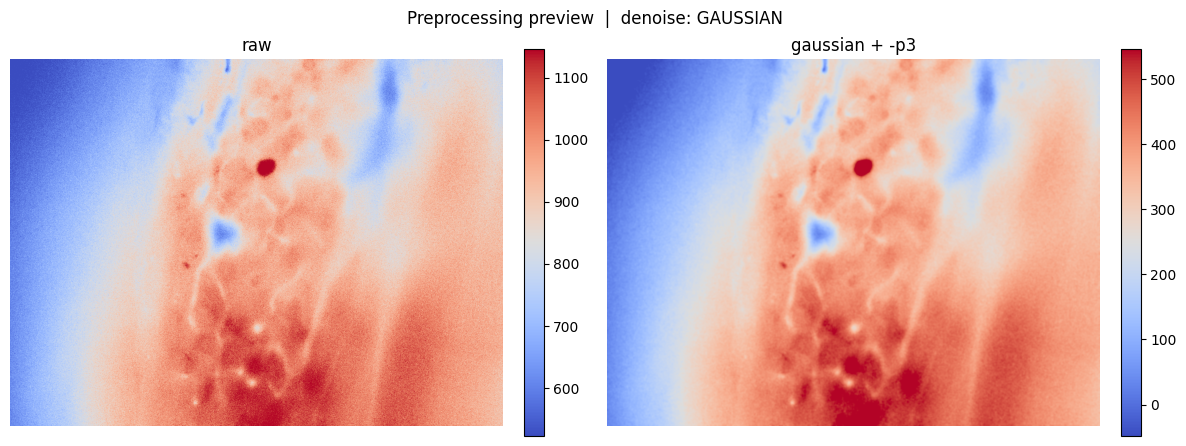

In [38]:
# --- Pick the denoise method and (optionally) tune its parameters ---------------
DENOISE_METHOD = "gaussian"     # "nlm" (recommended) or "gaussian"

# NLM parameters (used when DENOISE_METHOD == "nlm"); suggested defaults:
NLM_PATCH_SIZE = 5
NLM_PATCH_DISTANCE = 6
NLM_H_FACTOR = 1.15
# Gaussian parameter (used when DENOISE_METHOD == "gaussian"); suggested default:
GAUSSIAN_SIGMA = 2.0
# Background subtraction: subtract this per-frame intensity percentile (suggested default):
BACKGROUND_PERCENTILE = 3

# Human-readable tag stamped onto every downstream figure/movie title.
METHOD_LABEL = DENOISE_METHOD.upper()


def preprocess_frame(frame: np.ndarray) -> np.ndarray:
    """Denoise (per DENOISE_METHOD) then subtract the per-frame background percentile."""
    frame = frame.astype(np.float32)
    if DENOISE_METHOD == "nlm":
        frame = denoise_nlm(frame, NLM_PATCH_SIZE, NLM_PATCH_DISTANCE, NLM_H_FACTOR)
    elif DENOISE_METHOD == "gaussian":
        frame = denoise_gaussian(frame, GAUSSIAN_SIGMA)
    else:
        raise ValueError(f"DENOISE_METHOD must be 'nlm' or 'gaussian', got {DENOISE_METHOD!r}")
    return (frame - np.percentile(frame, BACKGROUND_PERCENTILE)).astype(np.float32)


# Preprocessed frames are cached one-per-.npy, keyed by method so switching is safe.
_PREP_DIR = CACHE_DIR / f"preprocessed_{DENOISE_METHOD}_ch{CHANNEL}"
_PREP_DIR.mkdir(exist_ok=True)


def load_preprocessed(i: int) -> np.ndarray:
    """Preprocessed frame i, computed once and cached to disk."""
    cache_file = _PREP_DIR / f"{i:07d}.npy"
    if cache_file.exists():
        return np.load(cache_file)
    out = preprocess_frame(load_frame(i))
    np.save(cache_file, out)
    return out


# Before/after preview with the selected method.
raw0 = load_frame(0).astype(np.float32)
prep0 = load_preprocessed(0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, img, title in [(axes[0], raw0, "raw"),
                       (axes[1], prep0, f"{DENOISE_METHOD} + -p{BACKGROUND_PERCENTILE}")]:
    vmin, vmax = np.percentile(img, [1, 99])
    im = ax.imshow(img, cmap="coolwarm", vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title); ax.axis("off")
fig.suptitle(f"Preprocessing preview  |  denoise: {METHOD_LABEL}")
fig.tight_layout(); save_fig(fig, f"2b_preprocessed_preview_{DENOISE_METHOD}"); plt.show()

## 3. Visualize

Views of the recording, plus an optional interactive napari viewer. Every figure/movie title
is stamped with the denoise method chosen in §2b.
1. ROIs (from your label TIFF) **marked on the max-projection map**.
2. **MP4** of the whole field over time, with the **ROI mask overlaid** so you can see where
   each ROI sits.
3. **dF/F trace of every ROI**.

### 3a. ROI masks

ROIs come from the integer label TIFF set in Config (`0` = background, each positive
integer = one ROI). If you don't have one yet, paint it in the **napari cell** below and
save it to `ROI_LABEL_PATH`.

In [39]:
def load_roi_masks(path: Path = ROI_LABEL_PATH, expected_shape=frame_shape):
    label_map = np.squeeze(tifffile.imread(path))
    if label_map.shape != expected_shape:
        raise ValueError(f"ROI label shape {label_map.shape} != frame shape {expected_shape}")
    label_map = np.rint(label_map).astype(np.int32)
    ids = np.unique(label_map)
    ids = ids[ids > 0]
    if ids.size == 0:
        raise ValueError(f"No positive labels in {path}")
    return label_map, ids, [label_map == i for i in ids]


label_map, roi_ids, roi_masks = load_roi_masks()
roi_names = [f"ROI {int(i)}" for i in roi_ids]
print(f"{len(roi_masks)} ROIs; areas (px): {[int(m.sum()) for m in roi_masks]}")

40 ROIs; areas (px): [2601, 2449, 3717, 3864, 3520, 3269, 4326, 3888, 4519, 5036, 2520, 1439, 2492, 1314, 3249, 5238, 3068, 3547, 3018, 3695, 3054, 2743, 1607, 2304, 2094, 2772, 2599, 3801, 3182, 1207, 4916, 7412, 4387, 2956, 2477, 6815, 6444, 6585, 4903, 3770]


### 3b. ROIs marked on the max-projection map

The pixelwise max over the whole recording (raw frames, cached) with every ROI outlined and
numbered — a static reference for where the ROIs sit.

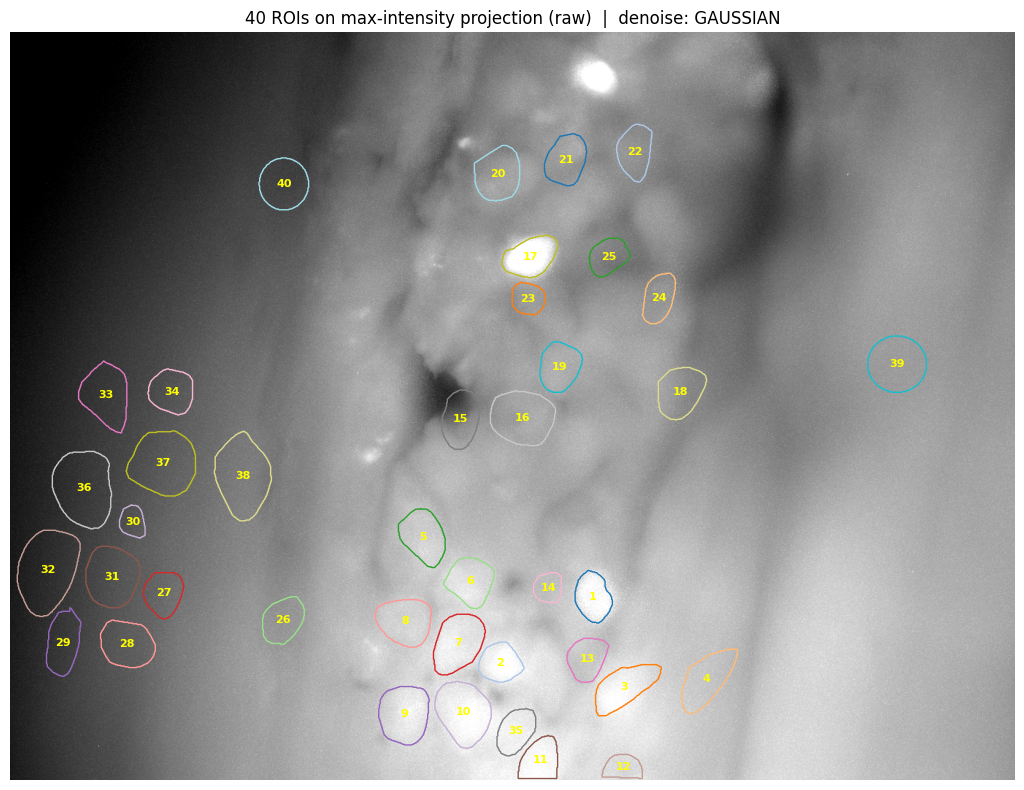

In [40]:
MAXPROJ_PATH = CACHE_DIR / f"max_projection_ch{CHANNEL}.npy"


def max_projection(path=MAXPROJ_PATH, overwrite=False):
    if path.exists() and not overwrite:
        return np.load(path)
    acc = None
    for i in tqdm(range(n_frames), desc="max projection"):
        f = load_frame(i)
        acc = f.copy() if acc is None else np.maximum(acc, f)
    np.save(path, acc)
    return acc


max_proj = max_projection()
vmin, vmax = np.percentile(max_proj, [2, 99.5])
fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(max_proj, cmap="gray", vmin=vmin, vmax=vmax)
for j, (m, name) in enumerate(zip(roi_masks, roi_names)):
    color = plt.cm.tab20(j % 20)
    ax.contour(m, levels=[0.5], colors=[color], linewidths=1.0)
    ys, xs = np.nonzero(m)
    ax.text(xs.mean(), ys.mean(), str(int(roi_ids[j])), color="yellow",
            fontsize=8, ha="center", va="center", weight="bold")
ax.set_title(f"{len(roi_masks)} ROIs on max-intensity projection (raw)  |  denoise: {METHOD_LABEL}")
ax.axis("off")
fig.tight_layout(); save_fig(fig, f"3b_rois_on_max_projection_{DENOISE_METHOD}"); plt.show()

### 3c. MP4 of the whole field (with ROI mask overlay)

Streams every frame to an H.264 MP4 without holding the stack in RAM, with the ROI mask
outlines + numbers drawn on top so you can see where each ROI sits in the moving field. A
single global contrast range keeps brightness from flickering. Requires `ffmpeg` on PATH.

In [41]:
from matplotlib import animation
from IPython.display import FileLink, Video, display

FRAME_STEP = 5          # 1 = every frame; larger = smaller/faster preview
PLAYBACK_FPS = 30
OVERLAY_ROIS = True     # draw ROI mask outlines + numbers on the movie (set False for a bare field)

# An MP4 must exist as a file to play inline. When SAVE_OUTPUTS is False we keep it in the
# cache (a working dir, not committed); when True we write it to OUTPUT_DIR (main_output/).
MOVIE_DIR = OUTPUT_DIR if SAVE_OUTPUTS else CACHE_DIR
MOVIE_PATH = MOVIE_DIR / f"whole_field_ch{CHANNEL}_step{FRAME_STEP}{'_roi' if OVERLAY_ROIS else ''}.mp4"


def render_movie(path=MOVIE_PATH, frame_step=FRAME_STEP, playback_fps=PLAYBACK_FPS,
                 overlay_rois=OVERLAY_ROIS, overwrite=False):
    if path.exists() and path.stat().st_size > 0 and not overwrite:
        print(f"Using cached movie: {path}")
        return path
    if not animation.writers.is_available("ffmpeg"):
        raise RuntimeError("ffmpeg is required (macOS: brew install ffmpeg).")
    path.parent.mkdir(parents=True, exist_ok=True)

    rows = np.arange(0, n_frames, frame_step)
    sample = np.linspace(0, n_frames - 1, min(12, n_frames)).astype(int)
    vmin, vmax = np.percentile(np.concatenate([load_frame(int(r))[::8, ::8].ravel() for r in sample]), [1, 99])

    fig, ax = plt.subplots(figsize=(9.6, 7.2))
    art = ax.imshow(load_frame(int(rows[0])), cmap="coolwarm", vmin=vmin, vmax=max(vmax, vmin + 1))
    if overlay_rois:  # ROI outlines + id numbers are static, so draw them once
        for j, m in enumerate(roi_masks):
            ax.contour(m, levels=[0.5], colors=[plt.cm.tab20(j % 20)], linewidths=0.7)
            ys, xs = np.nonzero(m)
            ax.text(xs.mean(), ys.mean(), str(int(roi_ids[j])), color="yellow",
                    fontsize=6, ha="center", va="center", weight="bold")
    title = ax.set_title("")
    ax.axis("off"); fig.subplots_adjust(left=0, right=1, bottom=0, top=0.95)

    roi_tag = f" | {len(roi_masks)} ROIs" if overlay_rois else ""
    writer = animation.FFMpegWriter(fps=playback_fps, codec="libx264", bitrate=4000,
                                    extra_args=["-pix_fmt", "yuv420p", "-movflags", "+faststart"])
    with writer.saving(fig, str(path), dpi=150):
        for r in tqdm(rows, desc="writing MP4"):
            art.set_data(load_frame(int(r)))
            title.set_text(f"Ch{CHANNEL} | raw frame {int(r)} | t={times_s[int(r)]:.1f}s"
                           f"{roi_tag} | denoise: {METHOD_LABEL}")
            writer.grab_frame()
    plt.close(fig)
    print(f"Saved {len(rows)} frames -> {path} ({path.stat().st_size / 1024**2:.1f} MB)")
    return path


movie_path = render_movie()
display(Video(str(movie_path), embed=False, html_attributes="controls preload='metadata'"))
display(FileLink(str(movie_path), result_html_prefix="Download MP4: "))

Using cached movie: analysis_cache/whole_field_ch0_step5_roi.mp4


/Users/samsonho/KSL/leftDRGcut/analysis_cache/whole_field_ch0_step5_roi.mp4

### 3d. dF/F trace of every ROI

One streaming pass averages the preprocessed pixels inside each ROI (cached), then a
rolling low-percentile baseline converts each fluorescence trace to fractional dF/F.
`dff` has shape `(n_frames, n_rois)` and is reused by sections 4 and 5.

extracting 40 ROI traces:   0%|          | 0/3220 [00:00<?, ?it/s]

dF/F (3220, 40)  range [-0.08, 0.38]


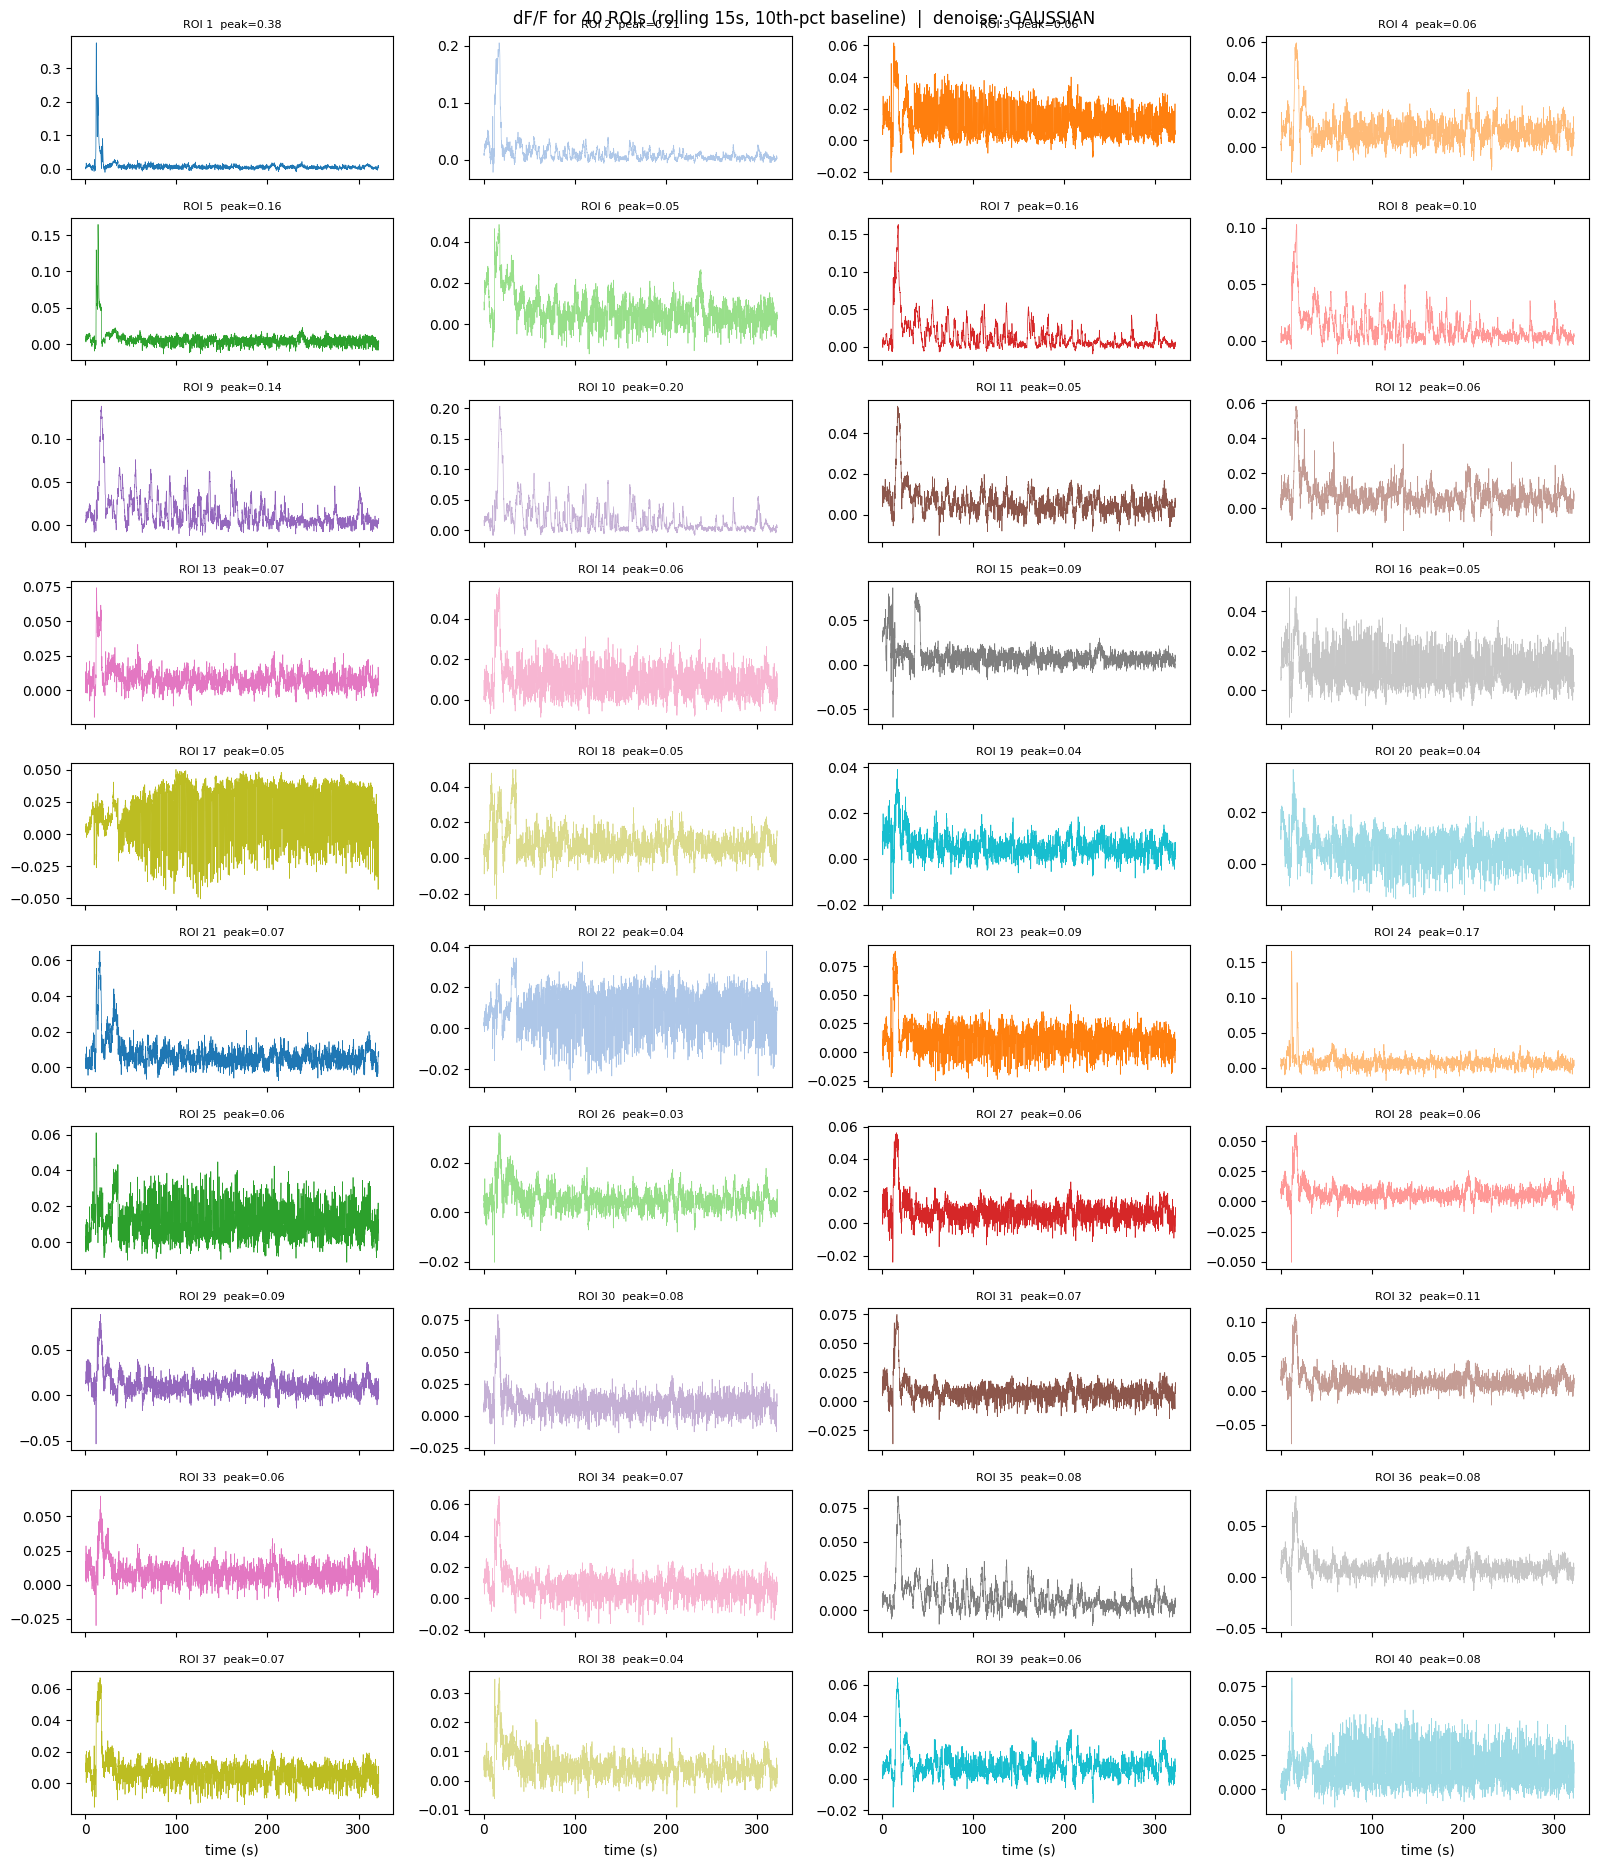

In [42]:
from scipy.ndimage import percentile_filter

TRACES_CACHE = CACHE_DIR / f"roi_traces_{DENOISE_METHOD}_ch{CHANNEL}_n{len(roi_masks)}.npy"


def extract_roi_traces(masks, cache_path=TRACES_CACHE, overwrite=False):
    """Mean preprocessed intensity inside each mask, per frame -> (n_frames, n_rois)."""
    if cache_path.exists() and not overwrite:
        F = np.load(cache_path)
        if F.shape == (n_frames, len(masks)):
            return F
    pixel_idx = [np.flatnonzero(m.ravel()) for m in masks]
    F = np.empty((n_frames, len(masks)), dtype=np.float32)
    for i in tqdm(range(n_frames), desc=f"extracting {len(masks)} ROI traces"):
        flat = load_preprocessed(i).ravel()
        for j, px in enumerate(pixel_idx):
            F[i, j] = flat[px].mean()
    np.save(cache_path, F)
    return F


def compute_dff(F):
    win = max(3, round(BASELINE_WINDOW_S / np.median(np.diff(times_s))))
    dff = np.empty_like(F)
    for j in range(F.shape[1]):
        f0 = np.clip(percentile_filter(F[:, j], BASELINE_PERCENTILE, size=win, mode="nearest"), 1e-3, None)
        dff[:, j] = (F[:, j] - f0) / f0
    return dff


roi_F = extract_roi_traces(roi_masks)
dff = compute_dff(roi_F)
print(f"dF/F {dff.shape}  range [{dff.min():.2f}, {dff.max():.2f}]")

# Small-multiples: dF/F for every ROI.
n_cols = 4
n_rows = int(np.ceil(len(roi_names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 1.9 * n_rows), sharex=True)
for j, ax in enumerate(axes.ravel()):
    if j >= len(roi_names):
        ax.axis("off"); continue
    ax.plot(times_s, dff[:, j], lw=0.5, color=plt.cm.tab20(j % 20))
    ax.set_title(f"{roi_names[j]}  peak={dff[:, j].max():.2f}", fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("time (s)")
fig.suptitle(f"dF/F for {len(roi_names)} ROIs (rolling {BASELINE_WINDOW_S}s, "
             f"{BASELINE_PERCENTILE}th-pct baseline)  |  denoise: {METHOD_LABEL}")
fig.tight_layout(); save_fig(fig, f"3d_dff_per_roi_{DENOISE_METHOD}"); plt.show()

### 3e. napari interactive viewer *(optional — off by default)*

Set `USE_NAPARI = True` in Config to open the recording in napari: the raw stack is added
lazily (via dask, so nothing is materialized), together with the max projection and an
editable ROI **Labels** layer. Paint ROIs with the brush, then run the save line to write
them to `ROI_LABEL_PATH` and re-run section 3a onward. Needs `napari` + `dask`, and a Qt
event loop (`%gui qt6`) in JupyterLab.

In [43]:
if USE_NAPARI:
    import dask.array as da
    import napari

    lazy = da.stack([
        da.from_delayed(da.delayed(load_frame)(i), shape=frame_shape, dtype=np.uint16)
        for i in range(n_frames)
    ], axis=0)

    viewer = napari.Viewer()
    viewer.add_image(lazy, name="raw_stack")
    viewer.add_image(max_proj, name="max_projection")
    roi_layer = viewer.add_labels(label_map.astype(np.uint16), name="ROI mask", opacity=0.6)

    # To persist edits, run this after painting:
    #   tifffile.imwrite(ROI_LABEL_PATH, roi_layer.data.astype(np.uint16))
    print("napari open. Paint ROIs on 'ROI mask', then save with the commented line above.")
else:
    print("napari disabled (USE_NAPARI = False). Set it True in Config to enable.")

napari disabled (USE_NAPARI = False). Set it True in Config to enable.


## 4. Spike inference — DS40-pretrained CASCADE

Each ROI's dF/F is sent to the official DS40 `Spinal_cord_excitatory_30Hz_smoothing50ms`
model. TensorFlow runs in the dedicated `CASCADE` conda env through `run_cascade_ds40.py`,
so this notebook's kernel doesn't need TensorFlow.

**Sampling-rate caveat:** this movie is ~10 Hz but the DS40 checkpoint is 30 Hz. The bridge
linearly resamples dF/F onto the 30 Hz grid, picks the noise-specific ensemble from noise
measured on the *original* trace, then sums 30 Hz spike bins back into the native bins — an
explicit approximation, not a validated 10 Hz inference.

loading cached CASCADE prediction: cascade_ds40_fd4b28de0695.npz
native 10.0 Hz (100 ms/bin) -> DS40 30 Hz -> native bins


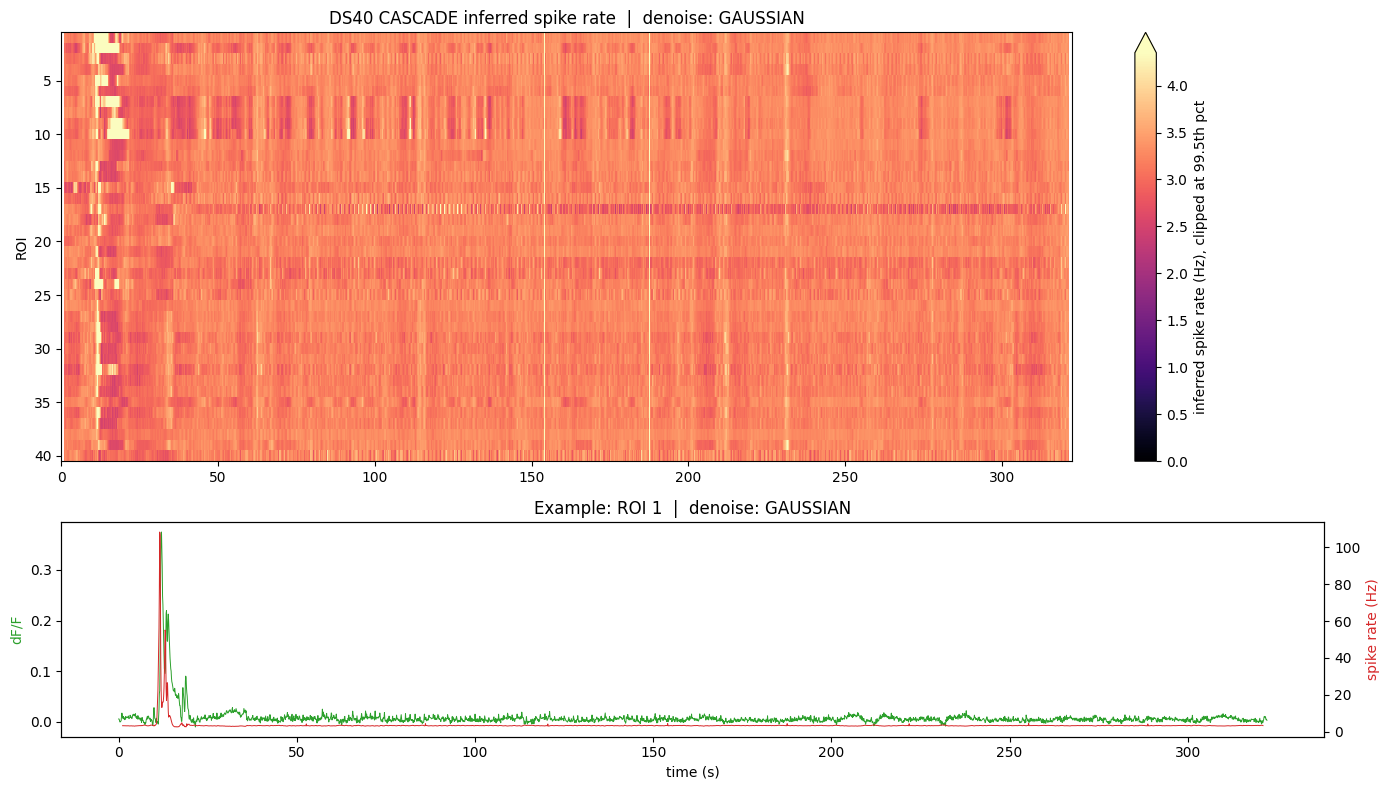

In [52]:
import hashlib
import os
import subprocess

t_native = times_s.astype(np.float64)
native_bin_s = float(np.median(np.diff(t_native)))     # ~0.1 s per native bin at 10 Hz
cascade_dff = dff.T.astype(np.float32)          # (n_rois, n_frames)
if not np.isfinite(cascade_dff).all():
    raise ValueError("dF/F has NaN/inf; inspect the baselines in section 3d before CASCADE.")

digest = hashlib.md5(cascade_dff.tobytes() + t_native.tobytes() + CASCADE_MODEL_NAME.encode()).hexdigest()[:12]
cascade_in = CACHE_DIR / f"cascade_input_{digest}.npz"
cascade_out = CACHE_DIR / f"cascade_ds40_{digest}.npz"

if not cascade_out.exists():
    if not CASCADE_ENV_PYTHON.is_file():
        raise FileNotFoundError(f"CASCADE env Python not found: {CASCADE_ENV_PYTHON} (set it in Config)")
    np.savez_compressed(cascade_in, traces=cascade_dff, time_s=t_native)
    env = os.environ.copy()
    env.update({"TF_CPP_MIN_LOG_LEVEL": "2", "KMP_DUPLICATE_LIB_OK": "TRUE", "PYTHONUNBUFFERED": "1",
                "MPLCONFIGDIR": str(CACHE_DIR / "mpl_cascade")})
    (CACHE_DIR / "mpl_cascade").mkdir(exist_ok=True)
    res = subprocess.run(
        [str(CASCADE_ENV_PYTHON), str(CASCADE_BRIDGE), "--input", str(cascade_in),
         "--output", str(cascade_out), "--cascade-root", str(CASCADE_ROOT), "--model", CASCADE_MODEL_NAME],
        env=env, text=True, capture_output=True,
    )
    print(res.stdout.strip())
    if res.returncode != 0:
        raise RuntimeError(f"CASCADE failed (exit {res.returncode}):\n{res.stderr}")
else:
    print(f"loading cached CASCADE prediction: {cascade_out.name}")

with np.load(cascade_out) as d:
    model_rate = float(d["model_rate_hz"])
    native_rate = float(d["native_rate_hz"])
    # Input is 10 Hz, so each native bin spans ~0.1 s. Express the DS40 output as a
    # per-second firing rate by dividing by the bin duration (0.00-0.40 -> 0.00-4.0 Hz).
    spike_rates = d["spike_rate_native_hz"].copy() / native_bin_s   # (n_rois, n_frames), Hz

print(f"native {native_rate:.1f} Hz ({native_bin_s * 1000:.0f} ms/bin) -> DS40 {model_rate:g} Hz -> native bins")

# Linear colour scale, but the single largest bin is a far outlier -- using it as vmax would
# push ~all pixels to the bottom (near-black) of the colormap. So clip the TOP of the scale
# to a high percentile (tune HEAT_CLIP_PCT); the few larger bins just saturate at full colour.
HEAT_CLIP_PCT = 99.5
finite = spike_rates[np.isfinite(spike_rates)]
vmin = 0.0
vmax = float(np.percentile(finite, HEAT_CLIP_PCT)) if finite.size else 1.0
if vmax <= vmin:                                       # degenerate (all-equal) fallback
    vmax = float(finite.max()) if finite.size else 1.0

fig, (ax_h, ax_ex) = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1])
im = ax_h.imshow(np.ma.masked_invalid(spike_rates), aspect="auto", interpolation="nearest",
                 cmap="magma", vmin=vmin, vmax=vmax,
                 extent=[t_native[0], t_native[-1], len(roi_names) + 0.5, 0.5])
fig.colorbar(im, ax=ax_h, extend="max",
             label=f"inferred spike rate (Hz), clipped at {HEAT_CLIP_PCT}th pct")
ax_h.set_ylabel("ROI")
ax_h.set_title(f"DS40 CASCADE inferred spike rate  |  denoise: {METHOD_LABEL}")

ax_ex.plot(t_native, dff[:, 0], color="tab:green", lw=0.7)
ax_ex.set_ylabel("dF/F", color="tab:green"); ax_ex.set_xlabel("time (s)")
ax_r = ax_ex.twinx()
ax_r.plot(t_native, spike_rates[0], color="tab:red", lw=0.7)
ax_r.set_ylabel("spike rate (Hz)", color="tab:red")
ax_ex.set_title(f"Example: {roi_names[0]}  |  denoise: {METHOD_LABEL}")
fig.tight_layout(); save_fig(fig, f"4_cascade_spike_rate_{DENOISE_METHOD}"); plt.show()

## 5. ROI correlation heatmaps

Pairwise Pearson correlation between ROIs, in natural ROI order (no reordering). A pair near
`r = 1` means those ROIs share a common signal — a real co-active network, or a field-wide
motion/illumination artifact worth inspecting.

- **5a** correlates the **dF/F** traces.
- **5b** correlates the **inferred (estimated) spike-rate** traces from §4.

### 5a. dF/F ROI correlation heatmap

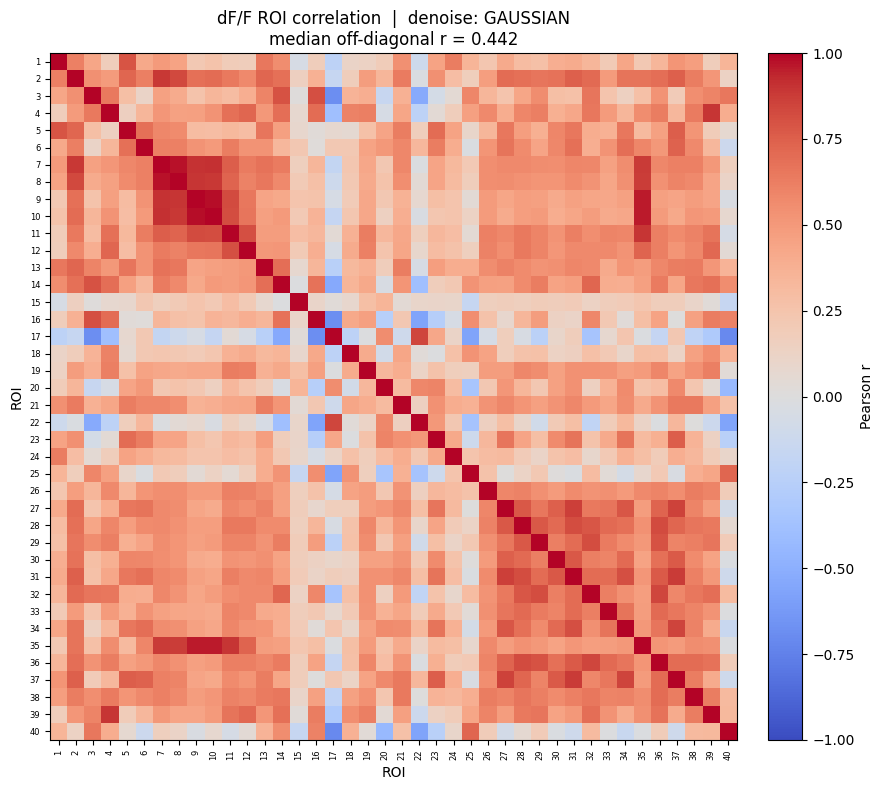

dF/F ROI correlation: median off-diagonal r = 0.442, max r = 0.979


In [53]:
def roi_corr_heatmap(traces, title, savename):
    """ROI x ROI Pearson correlation heatmap (natural ROI order).

    traces: (n_rois, n_time). Time bins with any non-finite value (e.g. CASCADE's
    edge padding) are dropped before correlating.
    """
    valid = np.isfinite(traces).all(axis=0)
    corr = np.corrcoef(traces[:, valid])
    iu = np.triu_indices(len(roi_names), 1)

    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
    ticks = range(len(roi_names))
    ax.set_xticks(ticks); ax.set_xticklabels([int(i) for i in roi_ids], fontsize=6, rotation=90)
    ax.set_yticks(ticks); ax.set_yticklabels([int(i) for i in roi_ids], fontsize=6)
    ax.set_xlabel("ROI"); ax.set_ylabel("ROI")
    ax.set_title(f"{title}  |  denoise: {METHOD_LABEL}\n"
                 f"median off-diagonal r = {np.median(corr[iu]):.3f}")
    fig.tight_layout(); save_fig(fig, savename); plt.show()
    print(f"{title}: median off-diagonal r = {np.median(corr[iu]):.3f}, max r = {corr[iu].max():.3f}")
    return corr


# 5a: correlation of the dF/F traces (dff is (n_frames, n_rois) -> transpose).
corr_dff = roi_corr_heatmap(dff.T, "dF/F ROI correlation", f"5a_dff_correlation_{DENOISE_METHOD}")

### 5b. Inferred spike-rate ROI correlation heatmap

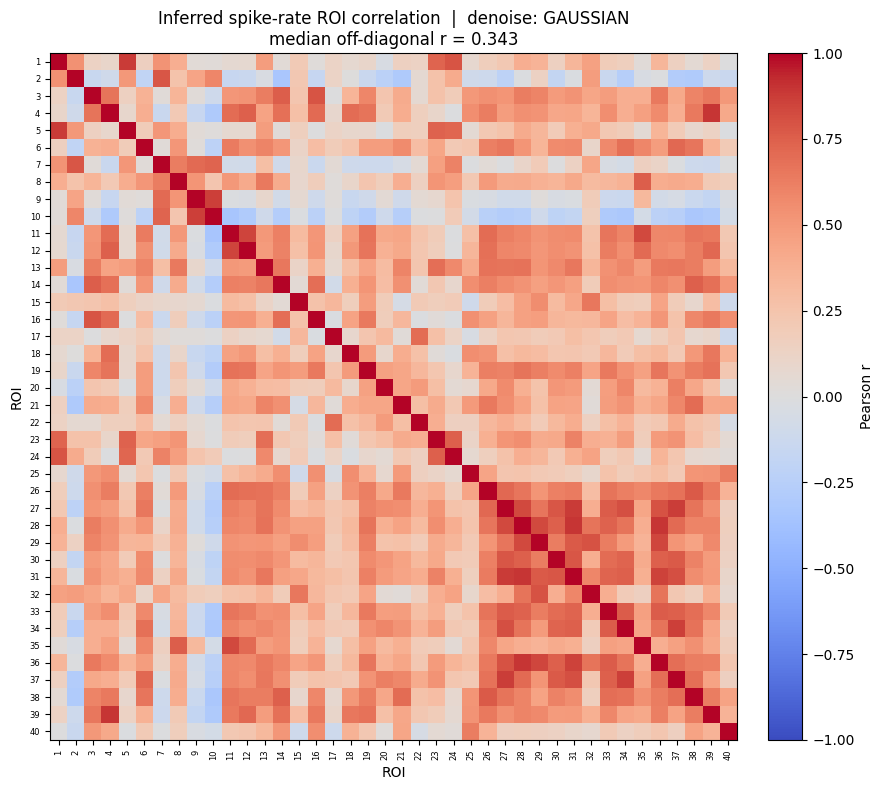

Inferred spike-rate ROI correlation: median off-diagonal r = 0.343, max r = 0.897


In [54]:
# 5b: correlation of the inferred (estimated) spike-rate traces from section 4.
# spike_rates is already (n_rois, n_frames); its NaN edge bins are dropped inside the helper.
corr_spikes = roi_corr_heatmap(
    spike_rates, "Inferred spike-rate ROI correlation", f"5b_spikerate_correlation_{DENOISE_METHOD}"
)